In [4]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
hdul = fits.open('data/dr16q_prop_May01_2024.fits')
fits_data = hdul[1].data  # Assuming the data is in the first extension    
fits_data2 = hdul[2].data  # Assuming the data is in the first extension    


fields1 = ['RA', 'DEC', 'SDSS_NAME', 'Z_SYS', 'LOGLBOL', 'LOGLBOL_ERR', 'LOGL3000', 'LOGL3000_ERR']
fields2 = ['M_I', 'SN_MEDIAN_ALL']

data = {}
for f in fields1:
    data[f] = fits_data[f]
for f in fields2:
    data[f] = fits_data2[f]

df_fits = pd.DataFrame(data)
df_fits['Z'] = df_fits['Z_SYS']

# Calculate LOGLBOL for each row in df_fits based on Z_SYS
df_fits['LOGLBOL_CALC'] = np.where(
    df_fits['Z'] < 0.7,
    np.log10(5.15) + df_fits['LOGL3000'],
    df_fits['LOGLBOL']
)
df_fits['LOGLBOL_ERR_CALC'] = np.where(
    df_fits['Z'] < 0.7,
    df_fits['LOGL3000_ERR'],
    df_fits['LOGLBOL_ERR']
)

df_fits['LOGLBOL'] = df_fits['LOGLBOL_CALC']
df_fits['LOGLBOL_ERR'] = df_fits['LOGLBOL_ERR_CALC']


In [18]:
from astropy.coordinates import search_around_sky

cat = pd.read_parquet(f"data/S82/Catalog.parquet").set_index('idx')

df_cat = cat.reset_index()[['objectId', 'RA', 'DEC']]

# Create SkyCoord objects for both catalogs
coords_cat = SkyCoord(ra=df_cat['RA'].values*u.deg, dec=df_cat['DEC'].values*u.deg)
coords_fits = SkyCoord(ra=df_fits['RA'].values*u.deg, dec=df_fits['DEC'].values*u.deg)

# Find matches within 1 arcsec
idx_cat, idx_fits, sep2d, _ = search_around_sky(coords_cat, coords_fits, 1*u.arcsec)

# Merge matched rows
df_merged = pd.concat([
    df_cat.iloc[idx_cat].reset_index(drop=True),
    df_fits.iloc[idx_fits].reset_index(drop=True)
], axis=1)

In [33]:
df = pd.read_csv('data/aug4_sample_chisqg10_ebv005sn3.csv', dtype={'object_id': str})
df['object_id']

df_merged_final = pd.merge(df, df_merged, left_on='object_id', right_on='objectId', how='inner')
df_merged_final = df_merged_final[df_merged_final['LOGLBOL'] > 41]

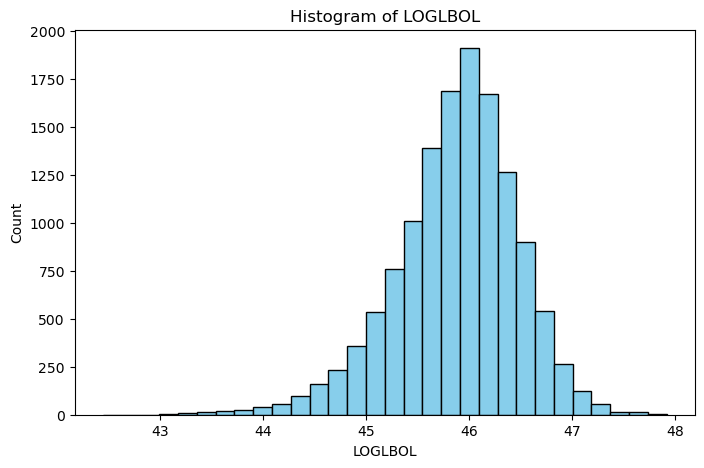

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(df_merged_final['LOGLBOL'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('LOGLBOL')
plt.ylabel('Count')
plt.title('Histogram of LOGLBOL')
plt.show()

In [39]:
bin_edges = np.linspace(df_merged_final['LOGLBOL'].min(), df_merged_final['LOGLBOL'].max(), 10)
print("Bin edges:", bin_edges)
df_merged_final['LOGLBOL_bin'] = pd.cut(df_merged_final['LOGLBOL'], bins=bin_edges)

for i, (bin_label, group) in enumerate(df_merged_final.groupby('LOGLBOL_bin')):
    group_shuffled = group.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"Processing bin: {i} {bin_label} with {len(group_shuffled)} entries")
    group_shuffled.to_csv(f'data/lbol_bins/sample_chisqg10_ebv005sn3_{i}.csv', index=False)


Bin edges: [42.44209497 43.05059531 43.65909564 44.26759598 44.87609631 45.48459665
 46.09309698 46.70159732 47.31009765 47.91859799]
Processing bin: 0 (42.442, 43.051] with 1 entries
Processing bin: 1 (43.051, 43.659] with 37 entries
Processing bin: 2 (43.659, 44.268] with 131 entries
Processing bin: 3 (44.268, 44.876] with 588 entries
Processing bin: 4 (44.876, 45.485] with 2195 entries
Processing bin: 5 (45.485, 46.093] with 5357 entries
Processing bin: 6 (46.093, 46.702] with 4046 entries
Processing bin: 7 (46.702, 47.31] with 773 entries
Processing bin: 8 (47.31, 47.919] with 38 entries


/tmp/ipykernel_2986038/2773937194.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (bin_label, group) in enumerate(df_merged_final.groupby('LOGLBOL_bin')):
